In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Missing values per column:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Data types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
dtype: object

Basic statistics:


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Data/crop_production.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (246091, 7)

Column names:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

First 5 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [6]:
# Check rows before cleaning
print("Before cleaning:", df.shape)

# Drop rows where Production is missing
df_clean = df.dropna(subset=['Production'])

# Check rows after cleaning
print("After cleaning:", df_clean.shape)

Before cleaning: (246091, 7)
After cleaning: (242361, 7)


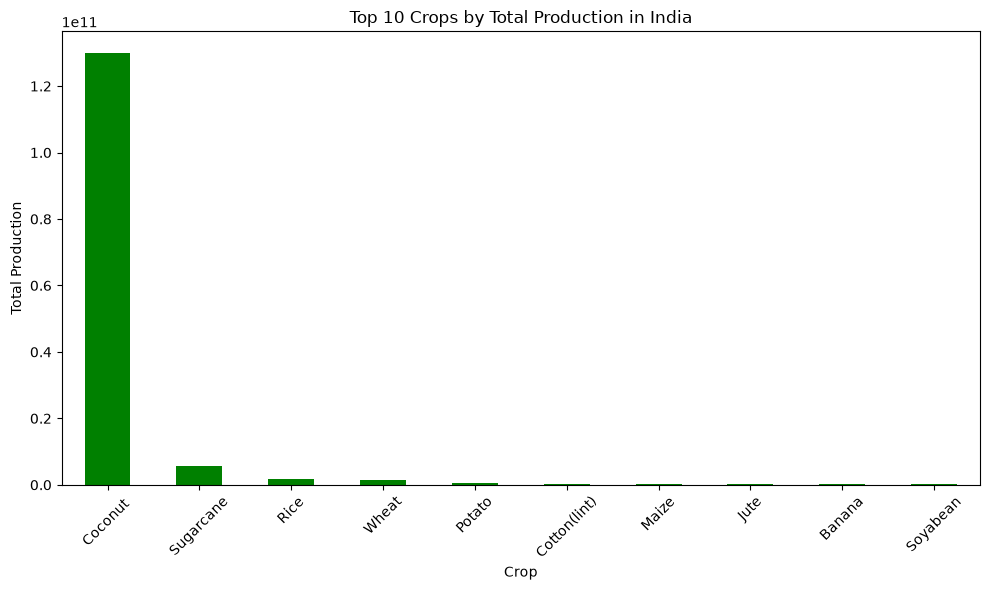

In [7]:
import matplotlib.pyplot as plt

# Top 10 crops by total production
top_crops = df_clean.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_crops.plot(kind='bar', color='green')
plt.title('Top 10 Crops by Total Production in India')
plt.xlabel('Crop')
plt.ylabel('Total Production')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
print(df_clean['Crop'].unique())

<StringArray>
[           'Arecanut', 'Other Kharif pulses',                'Rice',
              'Banana',           'Cashewnut',            'Coconut ',
          'Dry ginger',           'Sugarcane',        'Sweet potato',
             'Tapioca',
 ...
                 'Yam',            'Pump Kin',               'Apple',
               'Peach',                'Pear',               'Plums',
              'Litchi',                 'Ber',     'Other Dry Fruit',
        'Jute & mesta']
Length: 124, dtype: str


In [9]:
# Remove extra whitespace from crop names
df_clean['Crop'] = df_clean['Crop'].str.strip()

# Confirm total unique crops after cleaning
print("Total unique crops:", df_clean['Crop'].nunique())

Total unique crops: 124


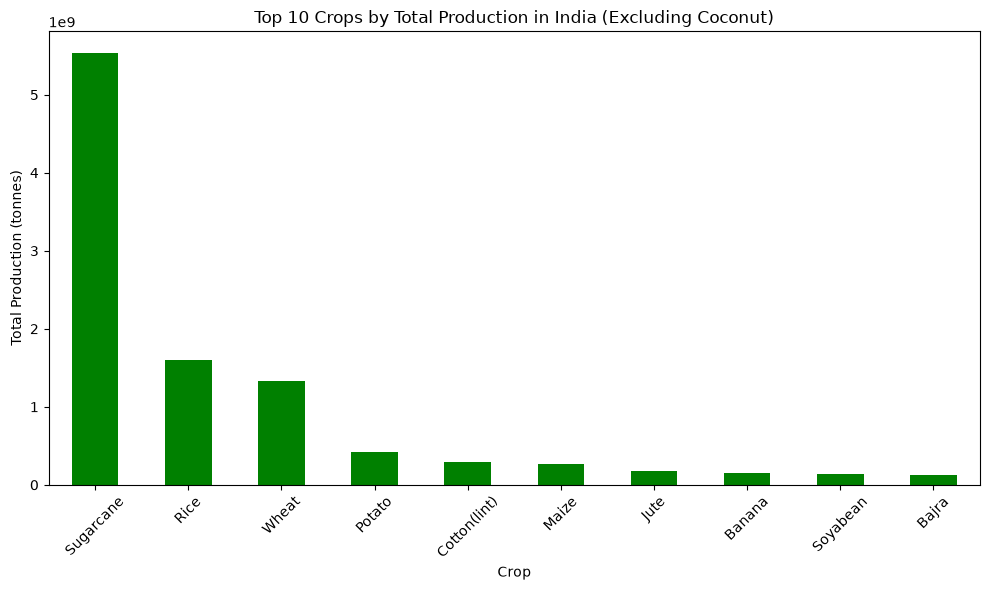

In [10]:
# Exclude Coconut (measured in nuts, not tonnes) for a fairer comparison
df_fair = df_clean[df_clean['Crop'] != 'Coconut']

top_crops_fair = df_fair.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_crops_fair.plot(kind='bar', color='green')
plt.title('Top 10 Crops by Total Production in India (Excluding Coconut)')
plt.xlabel('Crop')
plt.ylabel('Total Production (tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

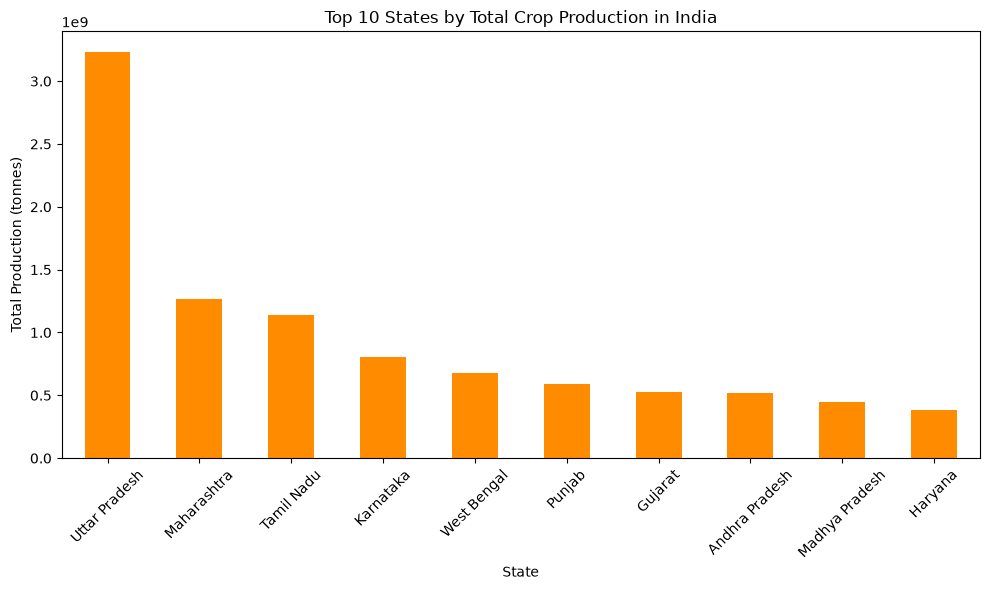

In [11]:
top_states = df_fair.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar', color='darkorange')
plt.title('Top 10 States by Total Crop Production in India')
plt.xlabel('State')
plt.ylabel('Total Production (tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

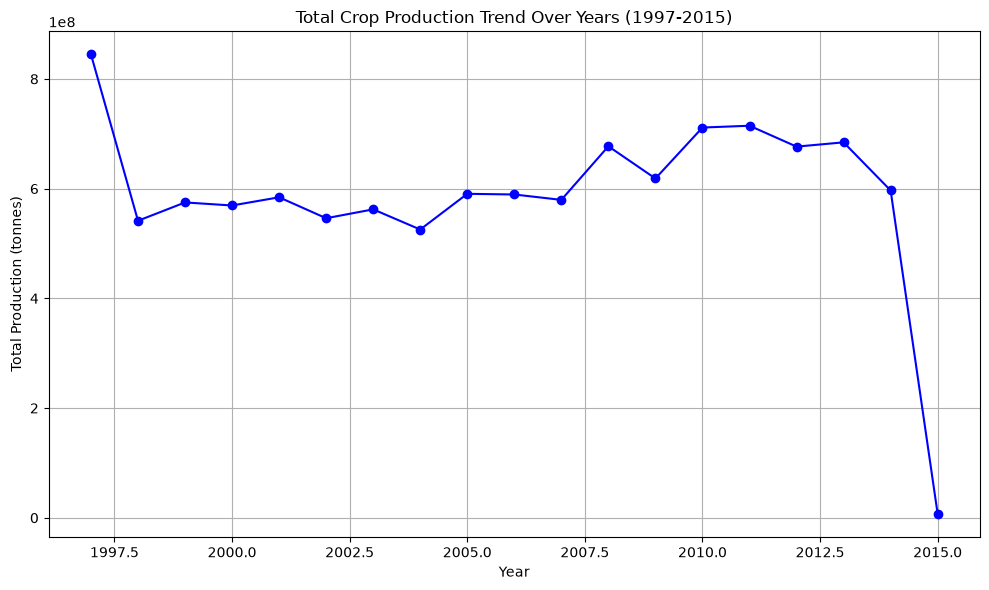

In [12]:
yearly_trend = df_fair.groupby('Crop_Year')['Production'].sum()

plt.figure(figsize=(10,6))
yearly_trend.plot(kind='line', marker='o', color='blue')
plt.title('Total Crop Production Trend Over Years (1997-2015)')
plt.xlabel('Year')
plt.ylabel('Total Production (tonnes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Check how many records exist per year
records_per_year = df_fair.groupby('Crop_Year').size()
print(records_per_year)

Crop_Year
1997     8842
1998    11179
1999    12355
2000    13445
2001    13186
2002    16402
2003    17005
2004    13720
2005    13405
2006    13837
2007    14146
2008    14092
2009    13645
2010    13715
2011    13667
2012    13097
2013    13353
2014    10751
2015      561
dtype: int64


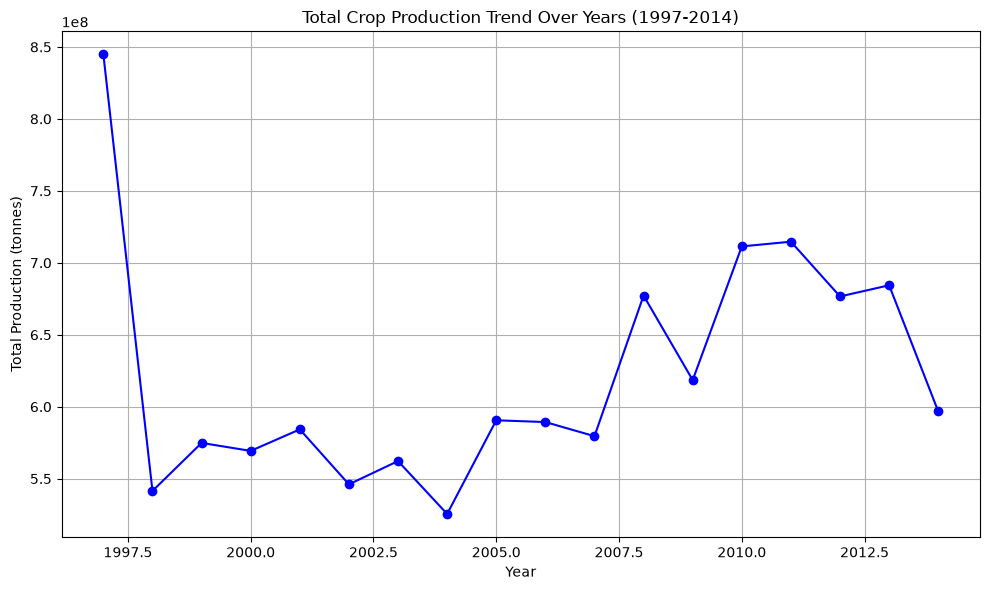

In [14]:
trend_clean = df_fair[df_fair['Crop_Year'] != 2015]
yearly_trend_clean = trend_clean.groupby('Crop_Year')['Production'].sum()

plt.figure(figsize=(10,6))
yearly_trend_clean.plot(kind='line', marker='o', color='blue')
plt.title('Total Crop Production Trend Over Years (1997-2014)')
plt.xlabel('Year')
plt.ylabel('Total Production (tonnes)')
plt.grid(True)
plt.tight_layout()
plt.show()

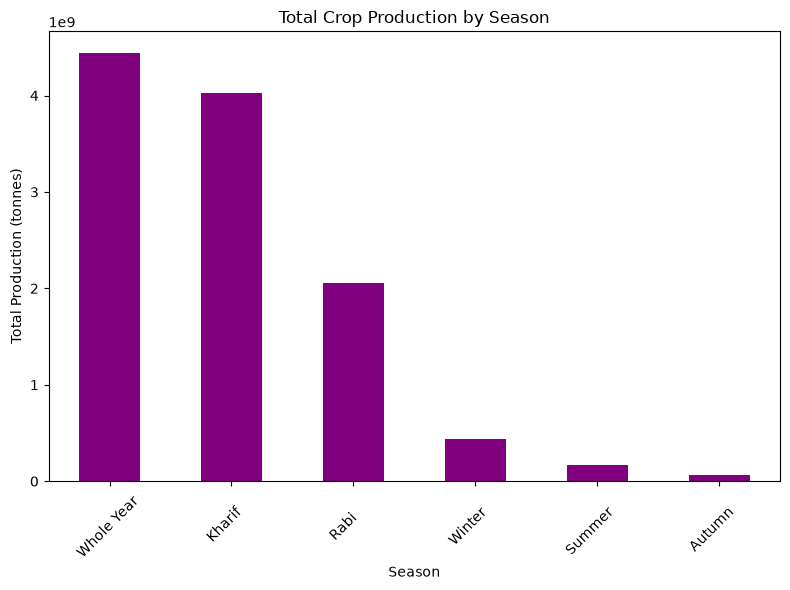

In [15]:
season_production = df_fair.groupby('Season')['Production'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
season_production.plot(kind='bar', color='purple')
plt.title('Total Crop Production by Season')
plt.xlabel('Season')
plt.ylabel('Total Production (tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

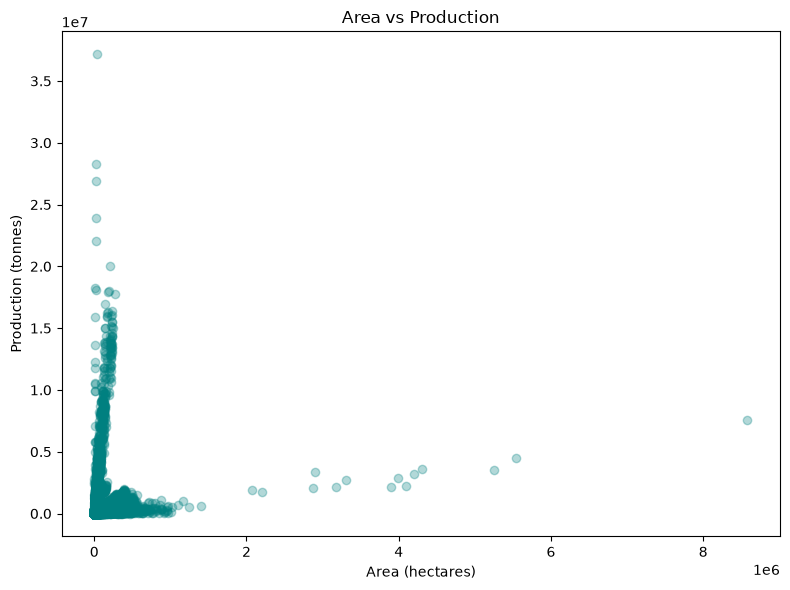

Correlation between Area and Production: 0.2415707402400217


In [16]:
plt.figure(figsize=(8,6))
plt.scatter(df_fair['Area'], df_fair['Production'], alpha=0.3, color='teal')
plt.title('Area vs Production')
plt.xlabel('Area (hectares)')
plt.ylabel('Production (tonnes)')
plt.tight_layout()
plt.show()

# Correlation coefficient
correlation = df_fair['Area'].corr(df_fair['Production'])
print("Correlation between Area and Production:", correlation)

In [17]:
# Select relevant columns for modeling
model_df = df_fair[['State_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']]
print(model_df.head())
print("\nShape:", model_df.shape)

                    State_Name  Crop_Year       Season                 Crop  \
0  Andaman and Nicobar Islands       2000  Kharif                  Arecanut   
1  Andaman and Nicobar Islands       2000  Kharif       Other Kharif pulses   
2  Andaman and Nicobar Islands       2000  Kharif                      Rice   
3  Andaman and Nicobar Islands       2000  Whole Year                Banana   
4  Andaman and Nicobar Islands       2000  Whole Year             Cashewnut   

     Area  Production  
0  1254.0      2000.0  
1     2.0         1.0  
2   102.0       321.0  
3   176.0       641.0  
4   720.0       165.0  

Shape: (240403, 6)


In [18]:
from sklearn.preprocessing import LabelEncoder

# Create encoders for each categorical column
le_state = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

model_df = model_df.copy()
model_df['State_encoded'] = le_state.fit_transform(model_df['State_Name'])
model_df['Season_encoded'] = le_season.fit_transform(model_df['Season'])
model_df['Crop_encoded'] = le_crop.fit_transform(model_df['Crop'])

print(model_df.head())

                    State_Name  Crop_Year       Season                 Crop  \
0  Andaman and Nicobar Islands       2000  Kharif                  Arecanut   
1  Andaman and Nicobar Islands       2000  Kharif       Other Kharif pulses   
2  Andaman and Nicobar Islands       2000  Kharif                      Rice   
3  Andaman and Nicobar Islands       2000  Whole Year                Banana   
4  Andaman and Nicobar Islands       2000  Whole Year             Cashewnut   

     Area  Production  State_encoded  Season_encoded  Crop_encoded  
0  1254.0      2000.0              0               1             2  
1     2.0         1.0              0               1            73  
2   102.0       321.0              0               1            94  
3   176.0       641.0              0               4             7  
4   720.0       165.0              0               4            22  


In [19]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = model_df[['State_encoded', 'Crop_Year', 'Season_encoded', 'Crop_encoded', 'Area']]
y = model_df['Production']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (192322, 5)
Testing set size: (48081, 5)


In [27]:
from sklearn.ensemble import RandomForestRegressor
import joblib

model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R² Score: 0.958446777254643
Mean Absolute Error: 8638.41941948321
Root Mean Squared Error: 79640.20668986408


In [28]:
import joblib

# Save the trained model and encoders
joblib.dump(model, 'crop_model.pkl', compress=3)
joblib.dump(le_state, 'le_state.pkl')
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_crop, 'le_crop.pkl')

# Also save the unique values for dropdowns in the UI
import json
unique_values = {
    'states': sorted(model_df['State_Name'].unique().tolist()),
    'seasons': sorted(model_df['Season'].unique().tolist()),
    'crops': sorted(model_df['Crop'].unique().tolist())
}
with open('unique_values.json', 'w') as f:
    json.dump(unique_values, f)

print("Model and supporting files saved successfully!")

Model and supporting files saved successfully!


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Train multiple models for comparison
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'R2 Score': r2, 'MAE': mae}
    print(f"{name}: R2 = {r2:.4f}, MAE = {mae:.2f}")

Linear Regression: R2 = 0.0741, MAE = 64591.97
Decision Tree: R2 = 0.7994, MAE = 10716.58
Random Forest: R2 = 0.9584, MAE = 8638.42


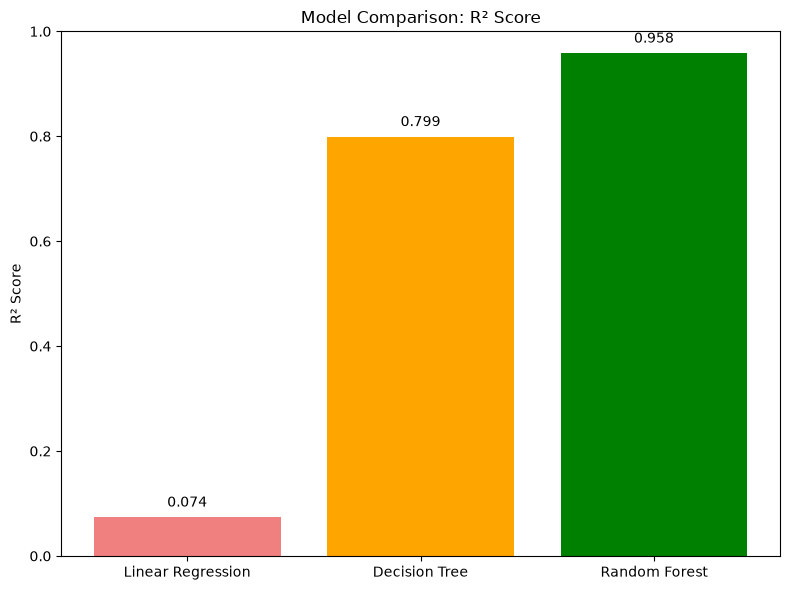

In [24]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
r2_scores = [results[m]['R2 Score'] for m in model_names]

plt.figure(figsize=(8,6))
bars = plt.bar(model_names, r2_scores, color=['lightcoral', 'orange', 'green'])
plt.title('Model Comparison: R² Score')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', ha='center')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

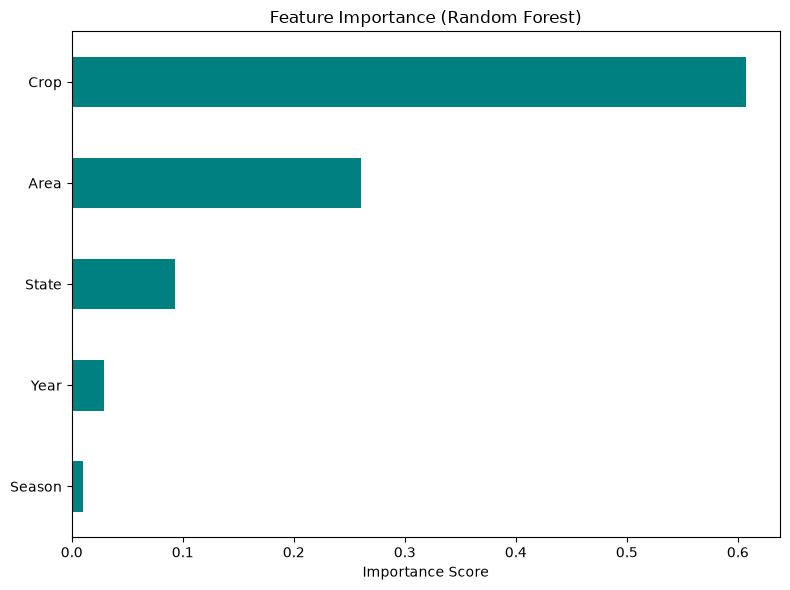

Crop      0.607597
Area      0.260349
State     0.093029
Year      0.029198
Season    0.009826
dtype: float64


In [25]:
import pandas as pd

# Get feature importance from Random Forest
feature_names = ['State', 'Year', 'Season', 'Crop', 'Area']
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feat_imp)

In [26]:
# Save data for the app: historical trends + model comparison results
df_fair[['State_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']].to_csv('app_data.csv', index=False)

import json
comparison_results = {name: {'R2 Score': float(results[name]['R2 Score']), 'MAE': float(results[name]['MAE'])} for name in results}
with open('model_comparison.json', 'w') as f:
    json.dump(comparison_results, f)

print("App data saved successfully!")

App data saved successfully!
